In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:\Users\Admin\Desktop\AI-Business-Risk-Intelligence"
sys.path.append(BASE)

from src.models.sentiment_analyzer import (
    create_sentiment_dataset,
    get_sentiment_summary
)

# Create sentiment dataset
sentiment_df = create_sentiment_dataset()

print("✅ Sentiment Analysis Complete!")
print(f"\nShape: {sentiment_df.shape}")
print("\nFirst 5 results:")
print(sentiment_df.head())

✅ Sentiment Analysis Complete!

Shape: (20, 5)

First 5 results:
   customer_id                                        feedback sentiment  \
0            0      The service is excellent and very reliable  Positive   
1            1       Very disappointed with the billing issues  Negative   
2            2             Good network coverage but expensive  Positive   
3            3  Worst customer service I have ever experienced  Negative   
4            4                  Happy with the service overall  Positive   

   sentiment_score  sentiment_risk  
0            0.572             0.0  
1           -0.526            52.6  
2            0.238             0.0  
3           -0.625            62.5  
4            0.572             0.0  


In [2]:
summary = get_sentiment_summary(sentiment_df)

print("📊 SENTIMENT ANALYSIS SUMMARY")
print("="*45)
print(f"Total Feedback      : {summary['total']}")
print(f"😊 Positive         : {summary['positive']} ({summary['positive_pct']}%)")
print(f"😐 Neutral          : {summary['neutral']} ({summary['neutral_pct']}%)")
print(f"😠 Negative         : {summary['negative']} ({summary['negative_pct']}%)")
print(f"⚠️  Avg Sentiment Risk: {summary['avg_risk']}%")

📊 SENTIMENT ANALYSIS SUMMARY
Total Feedback      : 20
😊 Positive         : 9 (45.0%)
😐 Neutral          : 4 (20.0%)
😠 Negative         : 7 (35.0%)
⚠️  Avg Sentiment Risk: 20.0%


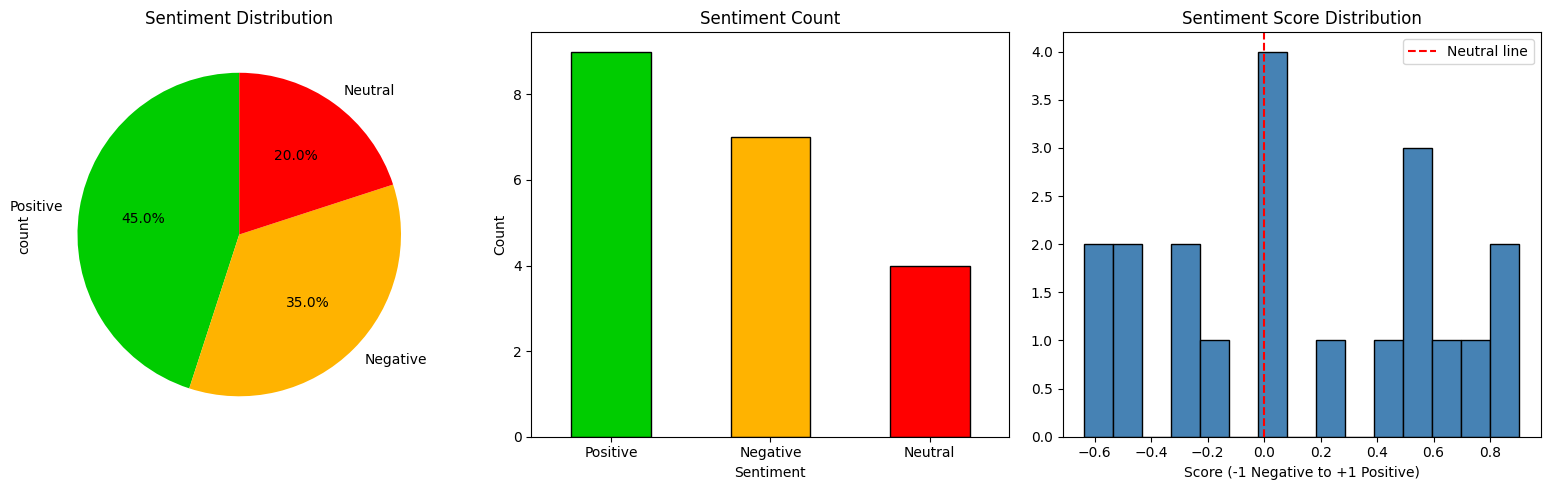

✅ Sentiment charts saved!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 — Pie chart
colors = ['#00CC00', '#FFB300', '#FF0000']
sentiment_df['sentiment'].value_counts().plot(
    kind='pie',
    ax=axes[0],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Sentiment Distribution')

# Chart 2 — Bar chart
sentiment_df['sentiment'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color=colors,
    edgecolor='black'
)
axes[1].set_title('Sentiment Count')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

# Chart 3 — Score distribution
axes[2].hist(
    sentiment_df['sentiment_score'],
    bins=15,
    color='steelblue',
    edgecolor='black'
)
axes[2].axvline(x=0, color='red', linestyle='--', label='Neutral line')
axes[2].set_title('Sentiment Score Distribution')
axes[2].set_xlabel('Score (-1 Negative to +1 Positive)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE, "docs", "sentiment_analysis.png"), dpi=150)
plt.show()
print("✅ Sentiment charts saved!")

In [4]:
print("🔴 HIGH RISK NEGATIVE FEEDBACK")
print("="*55)
negative = sentiment_df[sentiment_df['sentiment'] == 'Negative'].sort_values(
    'sentiment_risk', ascending=False
)
for _, row in negative.iterrows():
    print(f"\n⚠️  Customer {row['customer_id']}")
    print(f"   Feedback: {row['feedback']}")
    print(f"   Sentiment Risk: {row['sentiment_risk']}%")

🔴 HIGH RISK NEGATIVE FEEDBACK

⚠️  Customer 9
   Feedback: The charges are too high for poor service
   Sentiment Risk: 63.7%

⚠️  Customer 3
   Feedback: Worst customer service I have ever experienced
   Sentiment Risk: 62.5%

⚠️  Customer 1
   Feedback: Very disappointed with the billing issues
   Sentiment Risk: 52.6%

⚠️  Customer 15
   Feedback: Signal drops frequently very frustrating
   Sentiment Risk: 49.3%

⚠️  Customer 12
   Feedback: Decent service nothing special
   Sentiment Risk: 30.9%

⚠️  Customer 19
   Feedback: Planning to cancel subscription soon
   Sentiment Risk: 25.0%

⚠️  Customer 11
   Feedback: Very bad experience with customer care
   Sentiment Risk: 15.1%


In [5]:
sentiment_df.to_csv(
    os.path.join(BASE, "data", "processed", "sentiment_results.csv"),
    index=False
)
print("✅ Sentiment results saved!")
print("\n🎉 Sentiment Analysis Complete!")

✅ Sentiment results saved!

🎉 Sentiment Analysis Complete!
